# Variability of carbonate sensitivity

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from roms_tools import Grid, ROMSOutput
from matplotlib.lines import Line2D

## On ROMS grid for 2000-2001

### ROMS/MARBL

In [2]:
grid_file = "roms_marbl_dic/expCTRL/pacmed12_grd.nc"
grid = Grid.from_file(grid_file, theta_s=6.0, theta_b=6.0, hc=250.0, N=100)

2026-08-06 23:29:40 - INFO - === Preparing the vertical coordinate system using N = 100, theta_s = 6.0, theta_b = 6.0, hc = 250.0 ===
2026-08-06 23:29:40 - INFO - Total time: 0.004 seconds
2026-08-06 23:29:40 - INFO - ================================================================================================


In [3]:
ds_2000 = xr.open_mfdataset("roms_marbl_dic/expCTRL/BETA/carbonate_sensitivity_2000*.nc",
        combine="nested",
        concat_dim="time"
)
ds_2001 = xr.open_mfdataset("roms_marbl_dic/expCTRL/BETA/carbonate_sensitivity_2001*.nc",
        combine="nested",
        concat_dim="time"
)
ds_roms = xr.concat([ds_2000, ds_2001], dim="time")

In [4]:
for var in ["dDICdCO2", "dDICdALK"]:
    ds_roms[f"{var}_mean"] = ds_roms[var].mean(dim="time").compute()
    ds_roms[f"{var}_std"] = ds_roms[var].std(dim="time").compute()

/global/common/software/m4632/conda/romstools-test/lib/python3.13/site-packages/dask/array/numpy_compat.py:57: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/global/common/software/m4632/conda/romstools-test/lib/python3.13/site-packages/dask/array/numpy_compat.py:57: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


In [5]:
for var in ["dDICdCO2", "dDICdALK"]:
    mn = ds_roms[f"{var}_mean"].min().values
    mx = ds_roms[f"{var}_mean"].max().values
    std_mx = ds_roms[f"{var}_std"].max().values
    print(f"{var}: mean [{mn:.2f}, {mx:.2f}], std max {std_mx:.2f}")

dDICdCO2: mean [5.08, 31.76], std max 9.11
dDICdALK: mean [0.76, 0.92], std max 0.04


### CESM/ROMS

In [6]:
ds_2000 = xr.open_dataset(f"roms/exp3/INPUT/roms_surf_flux_2000.nc")
ds_2001 = xr.open_dataset(f"roms/exp3/INPUT/roms_surf_flux_2001.nc")
ds_cesm = xr.concat([ds_2000, ds_2001], dim="time")

In [7]:
for var in ["ddic_dco2", "ddic_dalk"]:
    ds_cesm[f"{var}_mean"] = ds_cesm[var].mean(dim="time").compute()
    ds_cesm[f"{var}_std"] = ds_cesm[var].std(dim="time").compute()

In [8]:
for var in ["ddic_dco2", "ddic_dalk"]:
    mn = ds_cesm[f"{var}_mean"].where(grid.ds.mask_rho).min().values
    mx = ds_cesm[f"{var}_mean"].where(grid.ds.mask_rho).max().values
    std_mx = ds_cesm[f"{var}_std"].where(grid.ds.mask_rho).max().values
    print(f"{var}: mean [{mn:.2f}, {mx:.2f}], std max {std_mx:.2f}")

ddic_dco2: mean [6.47, 28.07], std max 8.27
ddic_dalk: mean [0.78, 0.90], std max 0.03


## Ocean SODA

In [9]:
ds_2000 = xr.open_dataset(f"roms/exp8/INPUT/roms_surf_flux_2000.nc")
ds_2001 = xr.open_dataset(f"roms/exp8/INPUT/roms_surf_flux_2001.nc")
ds_soda = xr.concat([ds_2000, ds_2001], dim="time")

In [10]:
for var in ["ddic_dco2", "ddic_dalk"]:
    ds_soda[f"{var}_mean"] = ds_soda[var].mean(dim="time").compute()
    ds_soda[f"{var}_std"] = ds_soda[var].std(dim="time").compute()

In [11]:
for var in ["ddic_dco2", "ddic_dalk"]:
    mn = ds_soda[f"{var}_mean"].where(grid.ds.mask_rho).min().values
    mx = ds_soda[f"{var}_mean"].where(grid.ds.mask_rho).max().values
    std_mx = ds_soda[f"{var}_std"].where(grid.ds.mask_rho).max().values
    print(f"{var}: mean [{mn:.2f}, {mx:.2f}], std max {std_mx:.2f}")

ddic_dco2: mean [7.05, 25.21], std max 4.33
ddic_dalk: mean [0.78, 0.90], std max 0.03


## Plotting

In [12]:
def _add_coastlines_and_gridlines(ax):    
    # Add coastlines and land
    ax.coastlines()
    ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
    
    # Gridlines with labels only on left and bottom
    gl = ax.gridlines(
        draw_labels=True,
        linewidth=0.5,
        color="gray",
        x_inline=False,
        y_inline=False
    )
    gl.top_labels = False
    gl.right_labels = False

In [13]:
locations = {
    "J": {
        "release_center": {"eta_rho": 710, "xi_rho": 459},
        "color": "#df65b0"
    },    
    "V": {
        "release_center": {"eta_rho": 855, "xi_rho": 1135},
        "color": "#4CAF50"
    },
    "B": {
        "release_center": {"eta_rho": 650, "xi_rho": 1290},
        "color": "#2196F3"
    },
    "E": {
        "release_center": {"eta_rho": 490, "xi_rho": 1640},
        "color": "#FFA500"
    }
} 

In [14]:
def _add_locations(ax):
    for loc in locations:
        eta_rho = locations[loc]["release_center"]["eta_rho"]
        xi_rho = locations[loc]["release_center"]["xi_rho"]
        lon = grid.ds["lon_rho"][eta_rho, xi_rho].item()
        lat = grid.ds["lat_rho"][eta_rho, xi_rho].item()
        color = locations[loc]["color"]

        ax.plot(lon, lat, marker='o', color='none', markerfacecolor=color, markersize=8, transform=ccrs.PlateCarree())
    
    colors = [loc["color"] for loc in locations.values()]
    proxies = [Line2D([0], [0], marker='o', color='none', markerfacecolor=color, markersize=8) for color in colors]
    
    ax.legend(
        proxies,
        list(locations.keys()),
        loc="upper right",
        bbox_to_anchor=(1, 1.01),
        ncol=1,
        framealpha=1
    )

In [15]:
PLOT_CONFIG = {
    "beta": {
        "mean_colormap": "inferno",
        "mean_levels": np.arange(5, 31, 2.5),
        "std_vmax": 5,
        "title": r"$\beta$",
    },
    "eta": {
        "mean_colormap": "viridis",
        "mean_levels": np.arange(0.77, 0.9, 0.01),
        "std_vmax": 0.03,
        "title": r"$\eta$",
    },
}

In [16]:
def plot_mean_std(mean, std, data_str, variable="beta", with_locations=False, mean_extend="both", std_extend="max", ab_list=["(a)", "(b)"]):

    cfg = PLOT_CONFIG[variable]

    proj_roms = ccrs.PlateCarree(central_longitude=180)
    fig, axs = plt.subplots(1, 2, figsize=(15, 4), subplot_kw={"projection": proj_roms})
    norm = BoundaryNorm(cfg["mean_levels"], ncolors=plt.get_cmap(cfg["mean_colormap"]).N, extend=mean_extend)

    p = axs[0].pcolormesh(
        grid.ds["lon_rho"],
        grid.ds["lat_rho"],
        mean.where(grid.ds.mask_rho),
        cmap=cfg["mean_colormap"],
        norm=norm,
        transform=ccrs.PlateCarree(),
    )
    fig.colorbar(p, ax=axs[0], orientation="vertical", extend=mean_extend)
    axs[0].set_title(f"{ab_list[0]} Time Mean")

    p = axs[1].pcolormesh(
        grid.ds["lon_rho"],
        grid.ds["lat_rho"],
        std.where(grid.ds.mask_rho),
        transform=ccrs.PlateCarree(),
        cmap="GnBu",
        vmin=0,
        vmax=cfg["std_vmax"],
    )
    fig.colorbar(p, ax=axs[1], orientation="vertical", extend=std_extend)
    axs[1].set_title(f"{ab_list[1]} Standard Deviation")

    lon_min, lon_max = -93, 112
    for ax in axs:
        _add_coastlines_and_gridlines(ax)
        lat_min, lat_max = ax.get_extent(crs=proj_roms)[2:]
        ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj_roms)

        if with_locations:
            _add_locations(ax)

    fig.suptitle(cfg["title"] + ", " + data_str, fontsize=14)
    plt.tight_layout()

    return fig

### ROMS/MARBL

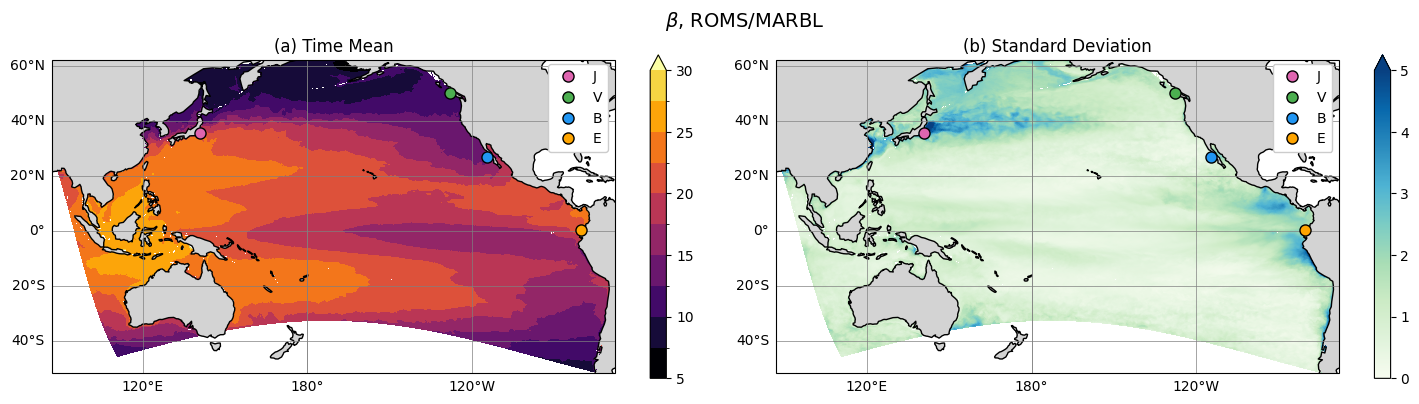

In [35]:
fig = plot_mean_std(ds_roms.dDICdCO2_mean, ds_roms.dDICdCO2_std, "ROMS/MARBL", variable="beta", mean_extend="max", with_locations=True, ab_list=["(a)", "(b)"])

In [36]:
fig.savefig(
    "figures/beta_ROMSMARBL_mean_std.png",
    dpi=300,
    bbox_inches="tight",
)

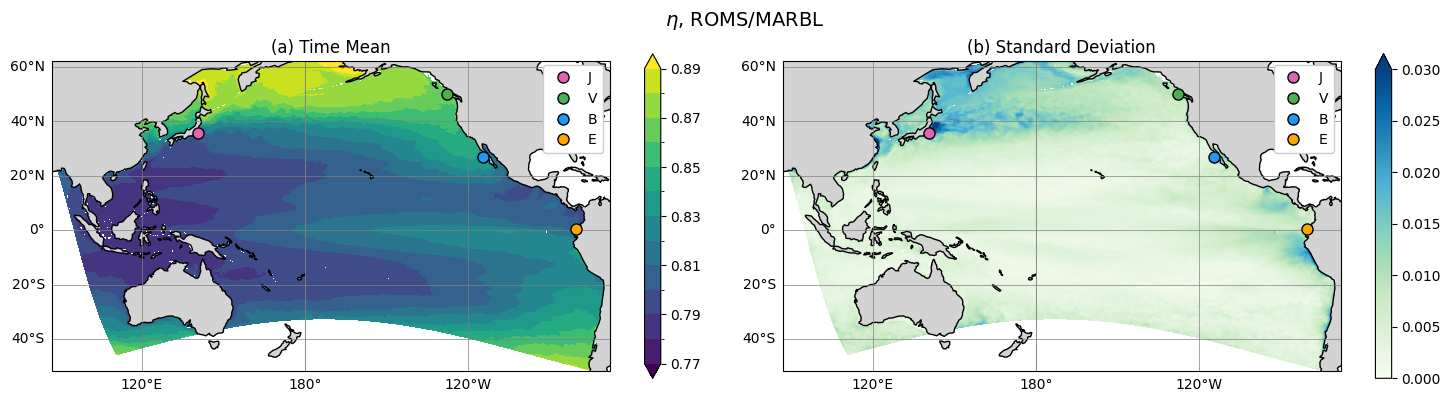

In [37]:
fig = plot_mean_std(ds_roms.dDICdALK_mean, ds_roms.dDICdALK_std, "ROMS/MARBL", variable="eta", mean_extend="both", with_locations=True, ab_list=["(a)", "(b)"])

In [38]:
fig.savefig(
    "figures/eta_ROMSMARBL_mean_std.png",
    dpi=300,
    bbox_inches="tight",
)

### CESM/MARBL

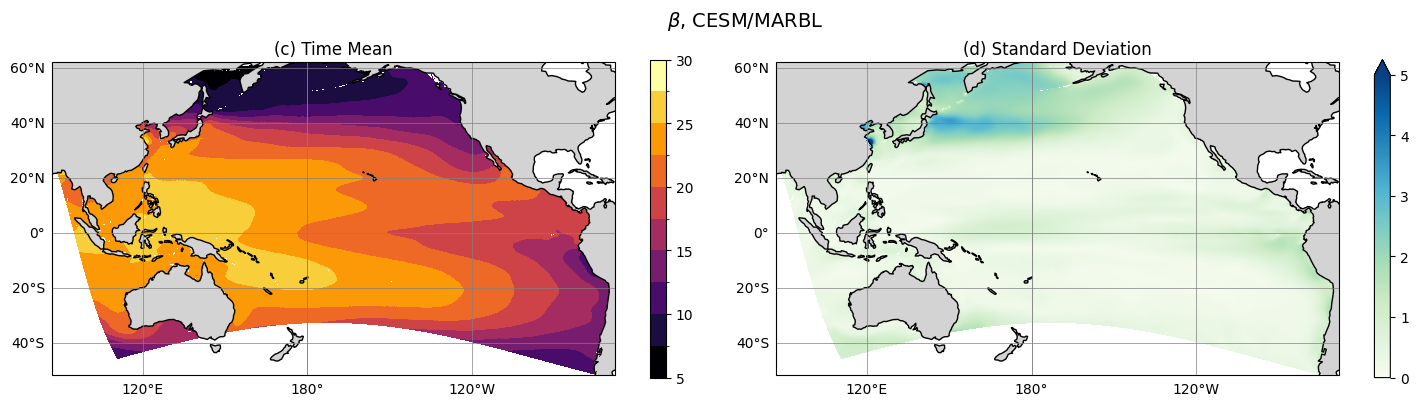

In [39]:
fig = plot_mean_std(ds_cesm.ddic_dco2_mean, ds_cesm.ddic_dco2_std, "CESM/MARBL", variable="beta", mean_extend="neither", ab_list=["(c)", "(d)"])

In [40]:
fig.savefig(
    "figures/beta_CESMMARBL_mean_std.png",
    dpi=300,
    bbox_inches="tight",
)

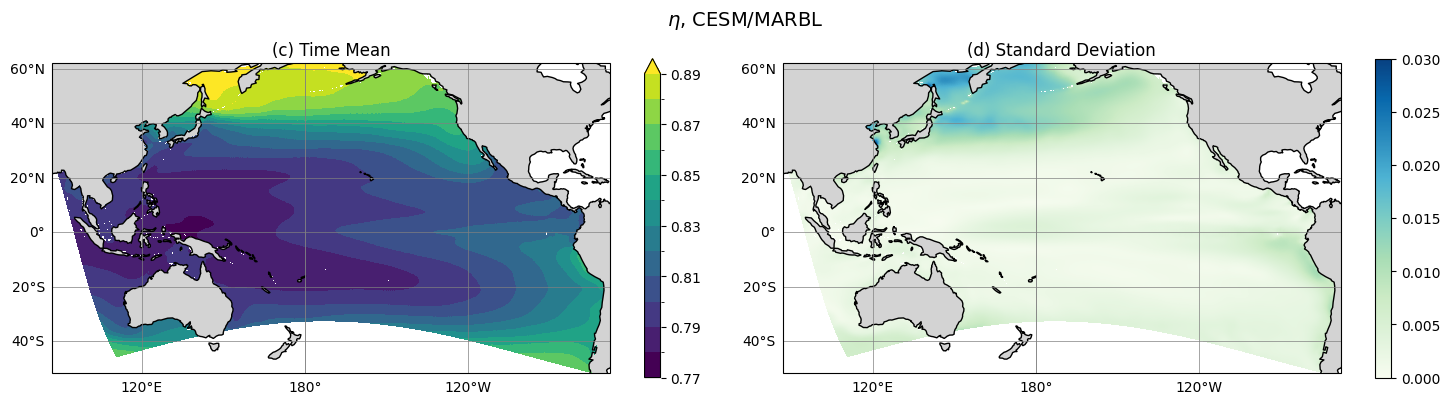

In [41]:
fig = plot_mean_std(ds_cesm.ddic_dalk_mean, ds_cesm.ddic_dalk_std, "CESM/MARBL", variable="eta", mean_extend="max", std_extend="neither", ab_list=["(c)", "(d)"])

In [42]:
fig.savefig(
    "figures/eta_CESMMARBL_mean_std.png",
    dpi=300,
    bbox_inches="tight",
)

### OceanSODA

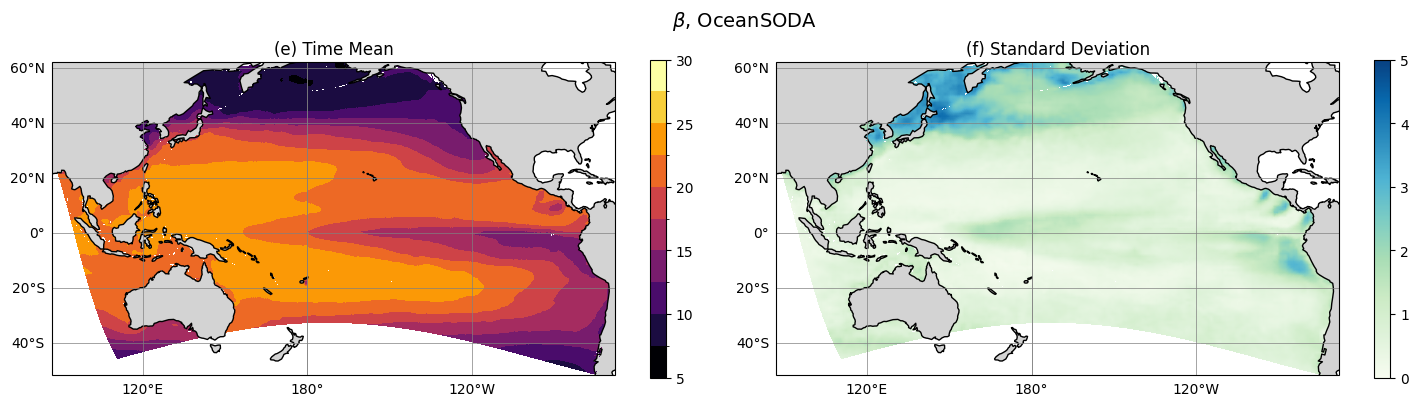

In [43]:
fig = plot_mean_std(ds_soda.ddic_dco2_mean, ds_soda.ddic_dco2_std, "OceanSODA", variable="beta", mean_extend="neither", std_extend="neither", ab_list=["(e)", "(f)"])

In [44]:
fig.savefig(
    "figures/beta_SODA_mean_std.png",
    dpi=300,
    bbox_inches="tight",
)

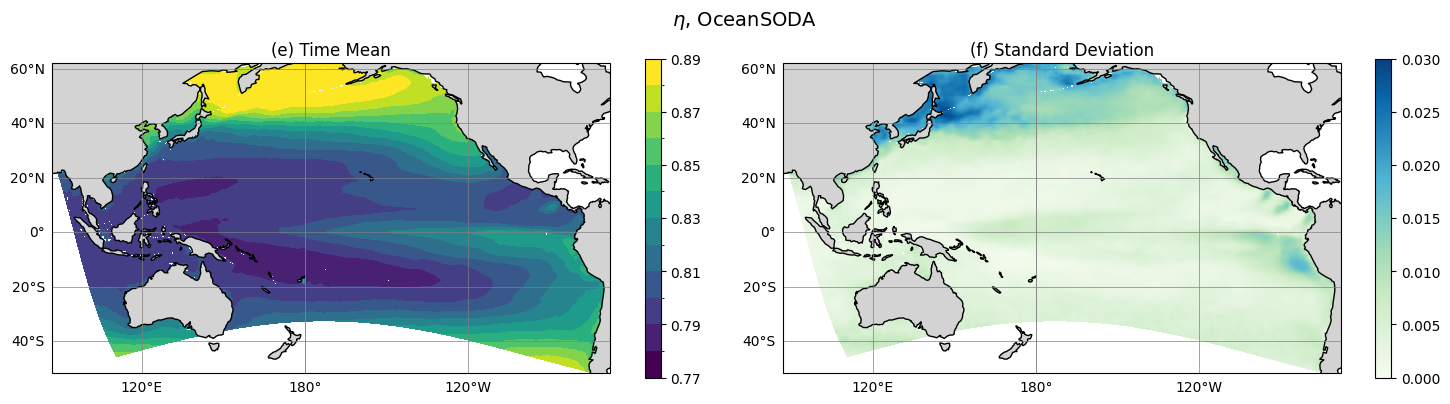

In [45]:
fig = plot_mean_std(ds_soda.ddic_dalk_mean, ds_soda.ddic_dalk_std, "OceanSODA", variable="eta", mean_extend="neither", std_extend="neither", ab_list=["(e)", "(f)"])

In [46]:
fig.savefig(
    "figures/eta_SODA_mean_std.png",
    dpi=300,
    bbox_inches="tight",
)

### Latitudinal dependence

Zonal mean of time-mean and time-std fields, binned into 1-degree latitude bands on the native curvilinear grid.

In [17]:
lat_rho = grid.ds["lat_rho"]
mask = grid.ds.mask_rho

lat_bins = np.arange(np.floor(float(lat_rho.min())), np.ceil(float(lat_rho.max())) + 1, 1)
lat_centers = 0.5 * (lat_bins[:-1] + lat_bins[1:])

def zonal_bin(da):
    """Bin a 2D field on the curvilinear grid into 1-degree latitude bins."""
    da_masked = da.where(mask).values.ravel()  # apply land mask, flatten to 1D
    lat_vals = lat_rho.values.ravel()           # matching 1D array of latitudes
    valid = np.isfinite(da_masked)              # keep only ocean points with data
    bin_idx = np.digitize(lat_vals[valid], lat_bins) - 1  # assign each point to a lat bin
    result = np.full(len(lat_centers), np.nan)
    for i in range(len(lat_centers)):
        sel = bin_idx == i                      # select all points in this lat band
        if sel.any():
            result[i] = np.nanmean(da_masked[valid][sel])  # zonal average within band
    return result

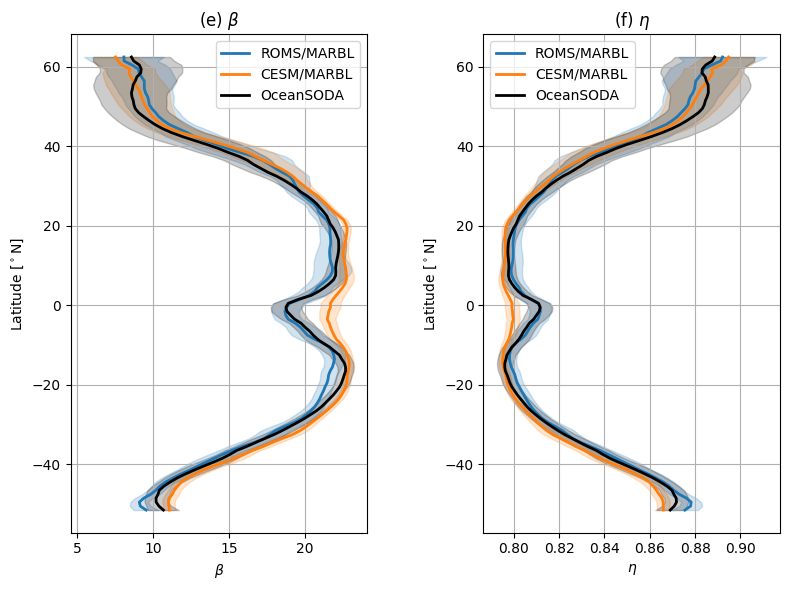

In [35]:
datasets_lat = [
    {"ds": ds_roms, "beta_mean": "dDICdCO2_mean", "beta_std": "dDICdCO2_std",
     "eta_mean": "dDICdALK_mean", "eta_std": "dDICdALK_std",
     "label": "ROMS/MARBL", "color": "C0"},
    {"ds": ds_cesm, "beta_mean": "ddic_dco2_mean", "beta_std": "ddic_dco2_std",
     "eta_mean": "ddic_dalk_mean", "eta_std": "ddic_dalk_std",
     "label": "CESM/MARBL", "color": "C1"},
    {"ds": ds_soda, "beta_mean": "ddic_dco2_mean", "beta_std": "ddic_dco2_std",
     "eta_mean": "ddic_dalk_mean", "eta_std": "ddic_dalk_std",
     "label": "OceanSODA", "color": "black"},
]

fig, axs = plt.subplots(1, 2, figsize=(8, 6))

for d in datasets_lat:
    ds = d["ds"]

    for ax, (mean_var, std_var) in zip(axs, [(d["beta_mean"], d["beta_std"]), (d["eta_mean"], d["eta_std"])]):
        mean = zonal_bin(ds[mean_var])
        std = zonal_bin(ds[std_var])
        ax.plot(mean, lat_centers, color=d["color"], label=d["label"], linewidth=2)
        ax.fill_betweenx(lat_centers, mean - std, mean + std, color=d["color"], alpha=0.2)

axs[0].set_title(r"(e) $\beta$")
axs[1].set_title(r"(f) $\eta$")

for ax in axs:
    ax.legend()
    ax.grid(True)
    ax.set_ylabel(r"Latitude [$^\circ$N]")

axs[0].set_xlabel(r"$\beta$")
axs[1].set_xlabel(r"$\eta$")

plt.tight_layout(w_pad=4)

In [36]:
fig.savefig(
    "figures/zonally_averaged_beta_eta_pacific.png",
    dpi=300,
    bbox_inches="tight",
)

### OceanSODA climatology on native lat-lon grid (full 1985-2014 period, Pacific vs. global)

Reload OceanSODA on its native 1-degree lat-lon grid (360 months). This lets us compare the Pacific domain to the global zonal mean, and show the monthly climatology.

In [25]:
ds_soda = xr.open_dataset("/global/cfs/projectdirs/m4746/Users/nora/Datasets/OceanSODA/OceanSODA_carbonate_sensitivity.nc")

In [26]:
ds_soda

<xarray.Dataset> Size: 373MB
Dimensions:   (time: 360, lat: 180, lon: 360)
Coordinates:
  * time      (time) datetime64[ns] 3kB 1993-01-15 1993-02-15 ... 2022-12-15
  * lat       (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon       (lon) float64 3kB -179.5 -178.5 -177.5 ... 177.5 178.5 179.5
Data variables:
    dDICdCO2  (time, lat, lon) float64 187MB ...
    dDICdALK  (time, lat, lon) float64 187MB ...

In [27]:
def get_seasonal_colormap():
    """Generate 12 monthly colors grouped and shaded by season."""
    winter = plt.cm.Blues(np.linspace(0.3, 0.9, 3))   # Dec, Jan, Feb
    spring = plt.cm.Greens(np.linspace(0.3, 0.9, 3))  # Mar, Apr, May
    summer = plt.cm.Oranges(np.linspace(0.3, 0.9, 3)) # Jun, Jul, Aug
    fall   = plt.cm.Grays(np.linspace(0.3, 0.9, 3))    # Sep, Oct, Nov

    return [
        winter[1], winter[2], spring[0], 
        spring[1], spring[2], summer[0], 
        summer[1], summer[2], fall[0],   
        fall[1],   fall[2], winter[0]
    ]

In [28]:
month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

def plot_latitudinal_dependence_clim(da, ax, title=""):

    colors = get_seasonal_colormap()

    da_zonal = da.mean(dim="lon")
    da_clim_mean = da_zonal.groupby("time.month").mean("time")
    da_clim_std = da_zonal.groupby("time.month").std("time")

    for month in range(1, 13):
        color = colors[month - 1]
        mean = da_clim_mean.sel(month=month)
        std = da_clim_std.sel(month=month)
        ax.plot(mean, mean.lat, linewidth=1.5, label=month_labels[month - 1], color=color)
        ax.fill_betweenx(mean.lat, mean - std, mean + std, alpha=0.15, color=color)

    ax.set_ylabel(r"Latitude [$^\circ$N]")
    ax.set_title(title)
    ax.grid(True)

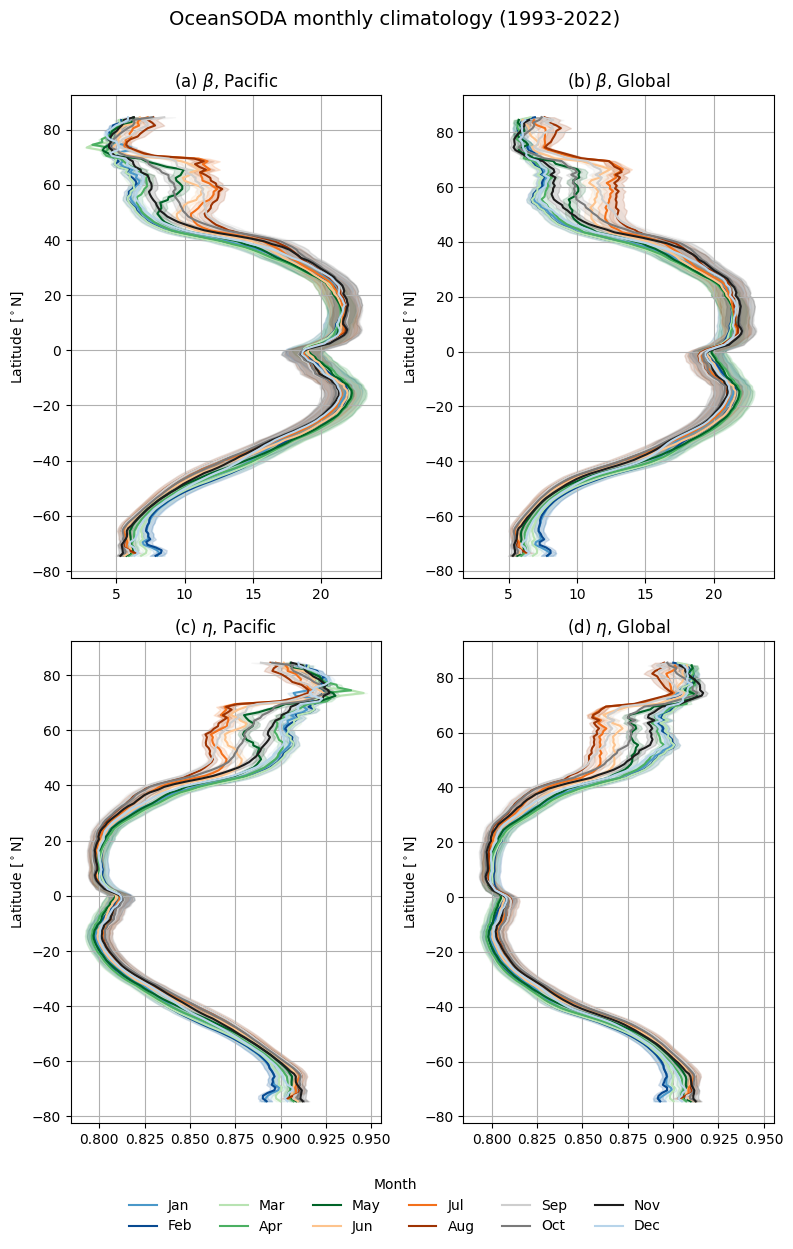

In [38]:
lon_rho = grid.ds["lon_rho"]
pac_lon_west = float(lon_rho.min()) + 360  # -280 -> ~80°E
pac_lon_east = float(lon_rho.max())        # ~-46°W

# Domain crosses the dateline: select lon >= 80 OR lon <= -46
pac_mask = (ds_soda.lon >= pac_lon_west) | (ds_soda.lon <= pac_lon_east)
ds_soda_pac = ds_soda.where(pac_mask)

fig, axs = plt.subplots(2, 2, figsize=(8, 12), sharex="row")

plot_latitudinal_dependence_clim(ds_soda_pac.dDICdCO2, axs[0, 0], title=r"(a) $\beta$, Pacific")
plot_latitudinal_dependence_clim(ds_soda.dDICdCO2,     axs[0, 1], title=r"(b) $\beta$, Global")
plot_latitudinal_dependence_clim(ds_soda_pac.dDICdALK, axs[1, 0], title=r"(c) $\eta$, Pacific")
plot_latitudinal_dependence_clim(ds_soda.dDICdALK,     axs[1, 1], title=r"(d) $\eta$, Global")

handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=6,
    frameon=False,
    title="Month",
)

fig.suptitle("OceanSODA monthly climatology (1993-2022)", y=1.01, fontsize=14)
plt.tight_layout(rect=[0, 0.05, 1, 1])

In [39]:
fig.savefig(
    "figures/SODA_climatology.png",
    dpi=300,
    bbox_inches="tight",
)